# Python para mirar imágenes como datos

**Tecnologías del Procesamiento de la Imagen Digital**  
**Clase 02 · Introducción a Python · 90 minutos**

Una imagen puede ser, al mismo tiempo, un archivo, un objeto de Pillow y una matriz de números. En este encuentro vamos a recorrer esas tres miradas y a convertir una exploración del cuaderno en un pequeño programa local.

## Al finalizar podremos

1. Preparar un entorno reproducible con `uv` y Python 3.12.
2. Localizar archivos de imagen con `pathlib`.
3. Abrir e inspeccionar una imagen con Pillow.
4. Comprender píxeles, dimensiones y canales mediante NumPy.
5. Visualizar y comparar resultados con Matplotlib.
6. Organizar transformaciones con funciones y una clase pequeña.
7. Comprender qué aporta un decorador a una función.
8. Exportar una función a un script y ejecutarla con Gradio.

> **Idea guía:** no vamos a estudiar Python primero y las imágenes después. Vamos a aprender Python mientras investigamos una imagen real.


## Recorrido de la clase

| Tiempo | Pregunta que guía el trabajo |
|---:|---|
| 0–10 min | ¿Qué Python está ejecutando este cuaderno y dónde están nuestros archivos? |
| 10–25 min | ¿Qué información contiene un archivo de imagen? |
| 25–45 min | ¿Cómo se convierte una imagen en números? |
| 45–55 min | ¿Cómo tomamos decisiones y repetimos operaciones? |
| 55–70 min | ¿Cómo construimos transformaciones reutilizables? |
| 70–78 min | ¿Qué problema resuelve una clase? |
| 78–84 min | ¿Qué hace realmente un decorador? |
| 84–90 min | ¿Cómo sale nuestro código del cuaderno? |

El cuaderno contiene algunas prácticas adicionales. No es necesario resolverlas todas durante los 90 minutos.


## Microglosario inicial

| Término | En lenguaje llano |
|---|---|
| **Intérprete** | El programa que lee y ejecuta código Python. |
| **Entorno virtual** | Una carpeta aislada que contiene el Python y los paquetes de un proyecto. |
| **Kernel** | El proceso que ejecuta las celdas y conserva sus variables en memoria. |
| **Ruta** | La ubicación de un archivo o una carpeta. |
| **Píxel** | Una muestra numérica ubicada en una coordenada de la imagen. |
| **Canal** | Una componente de información; en RGB usamos rojo, verde y azul. |
| **Array** | Una estructura NumPy que organiza valores en una o más dimensiones. |
| **Función** | Una transformación con nombre, entradas y una posible salida. |
| **Clase** | Un molde que reúne datos y operaciones relacionadas. |
| **Decorador** | Una función que añade comportamiento a otra función. |


### Para conversar

- ¿El intérprete está dentro de una carpeta llamada `.venv`?
- ¿Por qué la carpeta de trabajo y la carpeta del intérprete no son necesariamente la misma?
- Si elegimos otro kernel, ¿cambia el archivo del cuaderno o cambia quien lo ejecuta?


---

## 1. `pathlib`: antes de procesar una imagen, hay que encontrarla

Las rutas suelen escribirse como texto, pero `Path` permite tratarlas como objetos: podemos unir partes, consultar nombres, extensiones y recorrer carpetas sin depender de cómo cada sistema operativo escribe sus separadores.


In [38]:
from pathlib import Path

carpeta_clase = Path.cwd()
carpeta_imagenes = carpeta_clase / "Imagenes"
ruta_imagen = carpeta_imagenes / "escena_urbana.png"

print("Ruta completa:", ruta_imagen)
print("Nombre:", ruta_imagen.name)
print("Nombre sin extensión:", ruta_imagen.stem)
print("Extensión:", ruta_imagen.suffix)
print("Carpeta contenedora:", ruta_imagen.parent)
print("¿Existe?", ruta_imagen.exists())

assert ruta_imagen.is_file(), (
    "No se encontró la imagen. Abrí en VS Code la carpeta clase_02_python_pdi."
)


Ruta completa: c:\Users\Cynthia\Desktop\practica_pdi\Imagenes\escena_urbana.png
Nombre: escena_urbana.png
Nombre sin extensión: escena_urbana
Extensión: .png
Carpeta contenedora: c:\Users\Cynthia\Desktop\practica_pdi\Imagenes
¿Existe? True


In [39]:
# glob() busca elementos que siguen un patrón.
extensiones = ["*.png", "*.jpg", "*.jpeg"]
rutas_encontradas = []

for patron in extensiones:
    rutas_encontradas.extend(carpeta_imagenes.glob(patron))

for ruta in rutas_encontradas:
    print(f"{ruta.name:24} | {ruta.stat().st_size / 1024:.1f} KB")


escena_urbana.png        | 3344.4 KB


In [40]:
# Práctica breve
# 1. Construí con Path una ruta llamada ruta_salida dentro de una carpeta "resultados".
# 2. El archivo debe llamarse "escena_urbana_gris.png".
# 3. Mostrá su nombre, extensión y carpeta, sin crear todavía el archivo.

# Escribí tu solución debajo:


---

## 2. Pillow: la imagen como archivo visual

Pillow —que se importa como `PIL`— conoce formatos como PNG y JPEG. Se ocupa de abrir, convertir, recortar y guardar imágenes. Empezaremos con ella porque mantiene cerca la idea cotidiana de “una fotografía”.


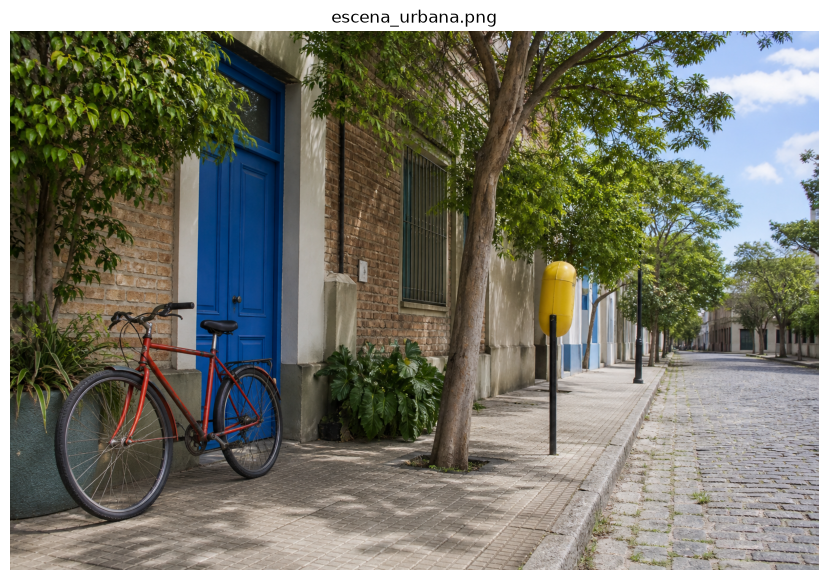

In [41]:
from PIL import Image
import matplotlib.pyplot as plt

with Image.open(ruta_imagen) as archivo:
    formato_original = archivo.format
    imagen = archivo.convert("RGB")

plt.figure(figsize=(12, 7))
plt.imshow(imagen)
plt.title(ruta_imagen.name)
plt.axis("off")
plt.show()


In [42]:
# Un diccionario reúne propiedades con nombres significativos.
ficha_imagen = {
    "archivo": ruta_imagen.name,
    "formato_original": formato_original,
    "modo": imagen.mode,
    "ancho": imagen.width,
    "alto": imagen.height,
    "cantidad_pixeles": imagen.width * imagen.height,
}

for clave, valor in ficha_imagen.items():
    print(f"{clave:20} -> {valor}")


archivo              -> escena_urbana.png
formato_original     -> PNG
modo                 -> RGB
ancho                -> 1536
alto                 -> 1024
cantidad_pixeles     -> 1572864


### Coordenadas de imagen

En Pillow una coordenada se expresa como `(x, y)`:

- `x` avanza horizontalmente desde la izquierda.
- `y` avanza verticalmente desde arriba.
- La esquina superior izquierda es `(0, 0)`.

Esto no es un detalle menor: más adelante NumPy nos obligará a mirar el mismo píxel con otro orden.


In [43]:
coordenada = (220, 620)
pixel_pillow = imagen.getpixel(coordenada)

print("Coordenada (x, y):", coordenada)
print("Valor RGB:", pixel_pillow)
print("Tipo:", type(pixel_pillow))


Coordenada (x, y): (220, 620)
Valor RGB: (75, 68, 36)
Tipo: <class 'tuple'>


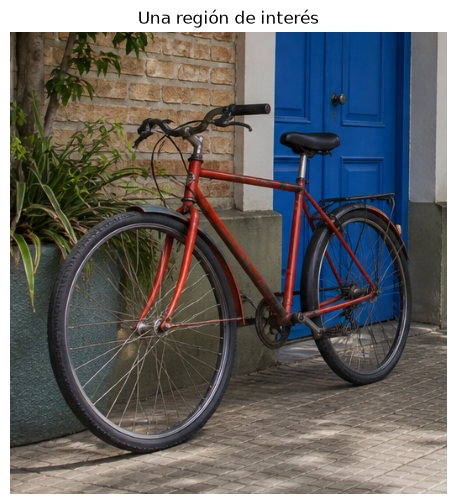

In [44]:
# crop() recibe una caja: (izquierda, arriba, derecha, abajo)
caja_bicicleta = (40, 430, 560, 980)
recorte_pillow = imagen.crop(caja_bicicleta)

plt.figure(figsize=(7, 6))
plt.imshow(recorte_pillow)
plt.title("Una región de interés")
plt.axis("off")
plt.show()


In [45]:
# Práctica breve
# Elegí otra región de la fotografía y recortala.
# Antes de ejecutar, anticipá qué debería aparecer.

# mi_caja = (..., ..., ..., ...)
# mi_recorte = imagen.crop(mi_caja)
# display(mi_recorte)


---

## 3. NumPy: la imagen como matriz de números

Al convertir la imagen a un array dejamos de verla solamente como una fotografía. Ahora podemos medirla, comparar valores y aplicar operaciones numéricas a millones de componentes a la vez.


In [46]:
import numpy as np

datos = np.asarray(imagen)

print("Tipo del objeto:", type(datos))
print("Forma:", datos.shape)
print("Tipo de cada valor:", datos.dtype)
print("Valor mínimo:", datos.min())
print("Valor máximo:", datos.max())
print(f"Memoria ocupada: {datos.nbytes / 1024**2:.2f} MB")


Tipo del objeto: <class 'numpy.ndarray'>
Forma: (1024, 1536, 3)
Tipo de cada valor: uint8
Valor mínimo: 0
Valor máximo: 255
Memoria ocupada: 4.50 MB


### Leer `shape` sin perderse

Para esta imagen, `datos.shape` tiene tres valores:

```text
(alto, ancho, canales)
```

El array se indexa como `datos[y, x]`, mientras que Pillow consulta `imagen.getpixel((x, y))`. Es la misma posición, pero el orden cambia porque NumPy piensa primero en filas y luego en columnas.

Cada canal usa enteros de 8 bits (`uint8`) entre 0 y 255. Un píxel RGB es una terna como `[rojo, verde, azul]`.


In [47]:
x, y = coordenada 
pixel_numpy = datos[y, x]  

print("Pillow:", pixel_pillow)
print("NumPy:", pixel_numpy)
print("¿Representan el mismo color?", np.array_equal(pixel_pillow, pixel_numpy))


Pillow: (75, 68, 36)
NumPy: [75 68 36]
¿Representan el mismo color? True


In [48]:
x, y = coordenada 
pixel_numpy = datos[x, y]

print("Pillow:", pixel_pillow)
print("NumPy:", pixel_numpy)
print("¿Representan el mismo color?", np.array_equal(pixel_pillow, pixel_numpy))


Pillow: (75, 68, 36)
NumPy: [71 52 31]
¿Representan el mismo color? False


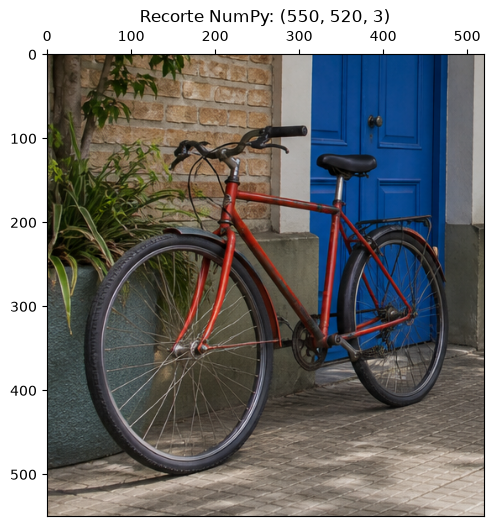

In [49]:
# El slicing de NumPy recorta filas y columnas.
recorte_numpy = datos[430:980, 40:560]

fig, ax = plt.subplots(figsize=(7, 6))

ax.imshow(recorte_numpy)
ax.set_title(f"Recorte NumPy: {recorte_numpy.shape}")

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

# Si querés que las etiquetas numéricas del eje x solo aparezcan arriba:
ax.tick_params(
    axis="x",
    bottom=False,
    top=True,
    labelbottom=False,
    labeltop=True
)

plt.show()

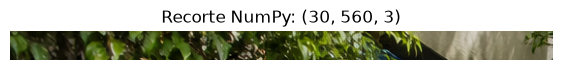

In [ ]:
recorte_numpy = datos[0:30, 0:560]
#filas de 0 a 30, columnas de 0 a 560
#se ven las primeras 30 filas de la imagen (y)
#y las primeras 560 columnas de la imagen (x)

plt.figure(figsize=(7, 6))
plt.imshow(recorte_numpy)
plt.title(f"Recorte NumPy: {recorte_numpy.shape}")
plt.axis("off")
plt.show()


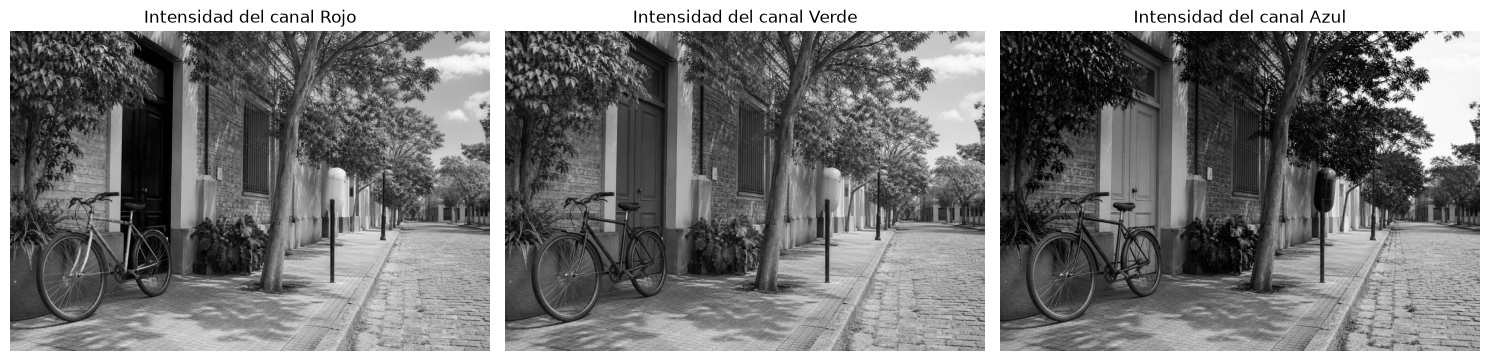

In [68]:
# Una lista conserva el orden; un diccionario aporta nombres.
nombres_canales = ["Rojo", "Verde", "Azul"]
indices_canales = {"Rojo": 0, "Verde": 1, "Azul": 2}

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

for eje, nombre in zip(ejes, nombres_canales):
    indice = indices_canales[nombre]
    eje.imshow(datos[:, :, indice], cmap="gray", vmin=0, vmax=255)
    eje.set_title(f"Intensidad del canal {nombre}")
    eje.axis("off")

plt.tight_layout()
plt.show()


### Para pensar

- ¿Por qué la puerta azul aparece clara en el canal azul y más oscura en otros?
- ¿Un canal aislado “tiene color” o contiene intensidades?
- ¿Qué estructura usamos para conservar un orden? ¿Cuál usamos para asociar un nombre con un índice?


---

## 4. Condiciones, operaciones y decisiones

No toda imagen necesita el mismo tratamiento. Podemos medir una propiedad y tomar una decisión. Para comenzar usaremos el promedio de los tres canales como una aproximación sencilla del brillo global.


In [52]:
brillo_medio = datos.mean()

if brillo_medio < 85:
    clasificacion = "oscura"
elif brillo_medio < 170:
    clasificacion = "intermedia"
else:
    clasificacion = "clara"

print(f"Brillo medio aproximado: {brillo_medio:.1f}")
print(f"Clasificación: {clasificacion}")


Brillo medio aproximado: 102.8
Clasificación: intermedia


In [53]:
# Sumamos intensidad a todos los componentes.
# int16 evita que uint8 desborde antes de aplicar clip().
datos_trabajo = datos.astype(np.int16)
datos_mas_claros = np.clip(datos_trabajo + 45, 0, 255).astype(np.uint8)

print("Antes:", datos.dtype, datos.min(), datos.max())
print("Después:", datos_mas_claros.dtype, datos_mas_claros.min(), datos_mas_claros.max())


Antes: uint8 0 255
Después: uint8 45 255


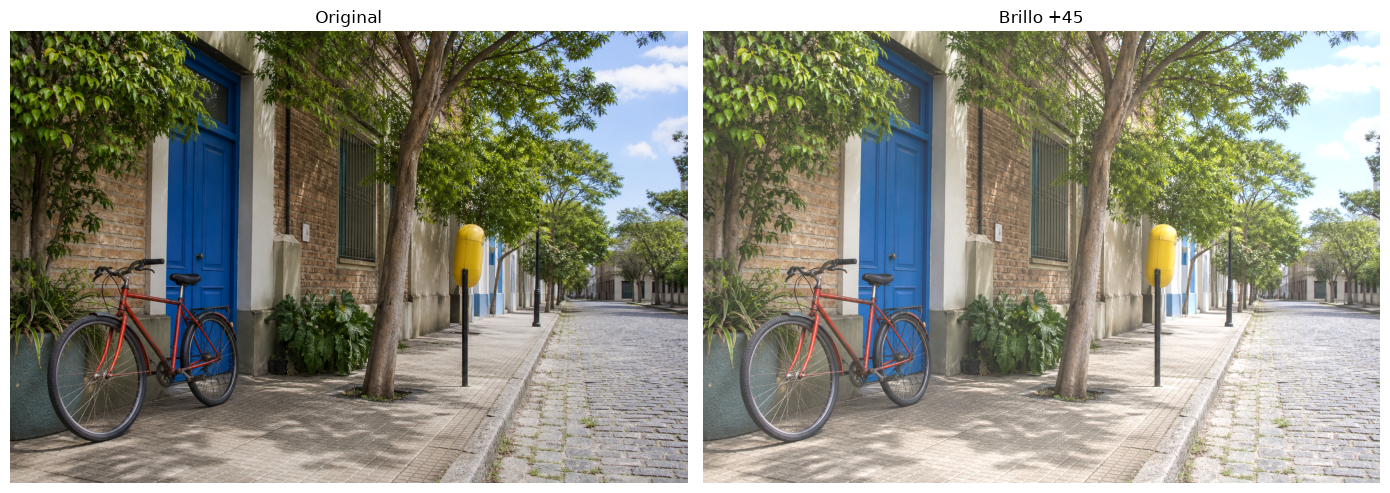

In [54]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))

ejes[0].imshow(datos)
ejes[0].set_title("Original")
ejes[0].axis("off")

ejes[1].imshow(datos_mas_claros)
ejes[1].set_title("Brillo +45")
ejes[1].axis("off")

plt.tight_layout()
plt.show()


In [55]:
# Práctica breve
# 1. Creá una versión 60 niveles más oscura.
# 2. ¿Por qué no conviene restar directamente sobre un array uint8?
# 3. Compará original, versión oscura y versión clara en una fila de gráficos.

# Escribí tu solución debajo:


---

## 5. Funciones: transformar sin repetir

Una buena función recibe datos, realiza una tarea clara y devuelve un resultado. Evitaremos que la función haga `print()` o dibuje: así podremos reutilizarla en el cuaderno, dentro de una clase y finalmente en una interfaz.


In [56]:
def ajustar_brillo(imagen_array, cambio=0):
    '''Devuelve una copia con el brillo ajustado entre 0 y 255.'''
    trabajo = imagen_array.astype(np.int16)
    ajustada = np.clip(trabajo + cambio, 0, 255)
    return ajustada.astype(np.uint8)


imagen_oscura = ajustar_brillo(datos, -55)
imagen_clara = ajustar_brillo(datos, 55)

print("Original:", datos.shape, datos.dtype)
print("Resultado:", imagen_clara.shape, imagen_clara.dtype)


Original: (1024, 1536, 3) uint8
Resultado: (1024, 1536, 3) uint8


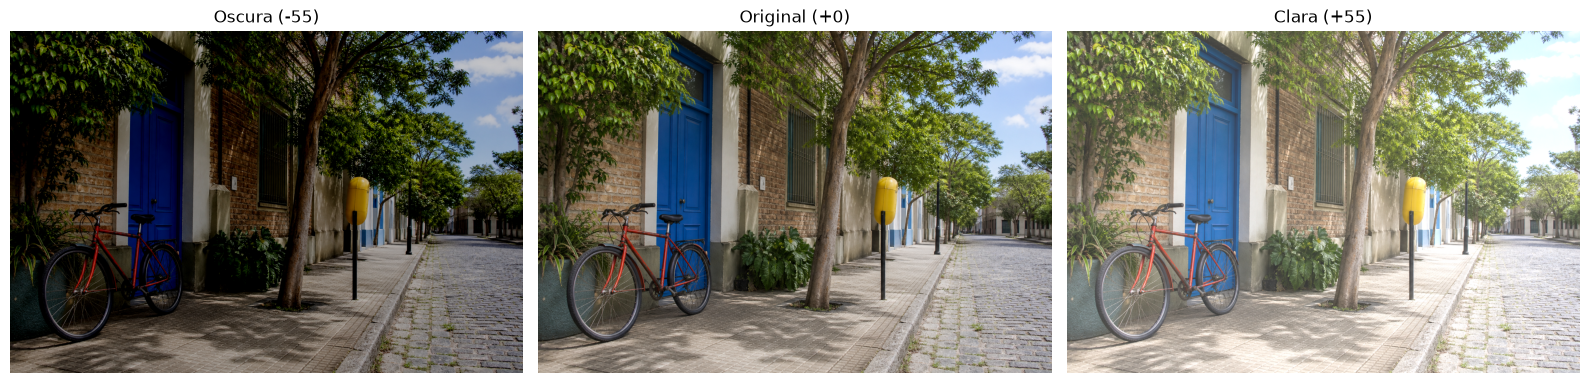

In [57]:
# La misma función, distintos argumentos.
variaciones = [
    ("Oscura", -55),
    ("Original", 0),
    ("Clara", 55),
]

fig, ejes = plt.subplots(1, len(variaciones), figsize=(16, 5))

for eje, (titulo, cambio) in zip(ejes, variaciones):
    resultado = ajustar_brillo(datos, cambio)
    eje.imshow(resultado)
    eje.set_title(f"{titulo} ({cambio:+d})")
    eje.axis("off")

plt.tight_layout()
plt.show()


In [58]:
def describir_imagen(imagen_array):
    '''Resume propiedades útiles sin modificar la imagen.'''
    alto, ancho, canales = imagen_array.shape
    return {
        "ancho": ancho,
        "alto": alto,
        "canales": canales,
        "dtype": str(imagen_array.dtype),
        "brillo_medio": float(imagen_array.mean()),
    }


resumen = describir_imagen(datos)

for clave, valor in resumen.items():
    print(f"{clave:15} -> {valor}")


ancho           -> 1536
alto            -> 1024
canales         -> 3
dtype           -> uint8
brillo_medio    -> 102.83440823025174


In [59]:
# Práctica breve
# Completá una función a_grises(imagen_array).
# Pista inicial: una aproximación simple es promediar los canales con axis=2.
# Debe devolver el resultado, no mostrarlo.

def a_grises(imagen_array):
    # resultado = ...
    # return resultado
    pass


---

## 6. Una introducción breve a clases

Hasta aquí tenemos objetos separados: una ruta, una imagen Pillow y un array. Una clase permite reunir ese estado y las operaciones que naturalmente pertenecen a una imagen de trabajo.

- La **clase** es el molde: `ImagenDigital`.
- Una **instancia** es un objeto concreto creado con una ruta.
- `self` representa esa instancia y conserva sus datos.
- Un **método** es una función que pertenece al objeto.

No buscamos todavía diseñar una biblioteca completa. Queremos reconocer el problema que una clase puede resolver.


In [60]:
class ImagenDigital:
    def __init__(self, ruta):
        self.ruta = Path(ruta)

        with Image.open(self.ruta) as archivo:
            self.imagen = archivo.convert("RGB")

        self.datos = np.asarray(self.imagen)

    def resumen(self):
        return describir_imagen(self.datos)

    def recortar(self, caja):
        return self.imagen.crop(caja)

    def ajustar_brillo(self, cambio=0):
        resultado = ajustar_brillo(self.datos, cambio)
        return Image.fromarray(resultado)


Ruta del objeto: c:\Users\Cynthia\Desktop\practica_pdi\Imagenes\escena_urbana.png
Resumen: {'ancho': 1536, 'alto': 1024, 'canales': 3, 'dtype': 'uint8', 'brillo_medio': 102.83440823025174}


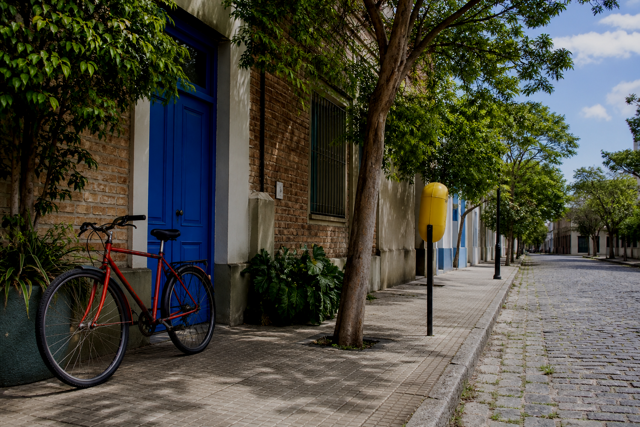

In [61]:
foto = ImagenDigital(ruta_imagen)

print("Ruta del objeto:", foto.ruta)
print("Resumen:", foto.resumen())

resultado_clase = foto.ajustar_brillo(-35)
display(resultado_clase.resize((640, 427)))


### Para pensar

- ¿Qué datos quedan guardados dentro de `foto`?
- ¿Qué diferencia conceptual hay entre `ajustar_brillo(datos, -35)` y `foto.ajustar_brillo(-35)`?
- Para una sola operación, una función suele ser suficiente. ¿Cuándo empieza a resultar útil agrupar estado y métodos?


---

## 7. Decoradores: añadir comportamiento sin cambiar la tarea

Un decorador recibe una función y devuelve otra función. La tarea original puede seguir siendo “invertir colores”, mientras el decorador añade una responsabilidad transversal, por ejemplo medir cuánto tarda.

La sintaxis `@medir_tiempo` es una forma legible de envolver una función. En el decorador aparecerán `*args` y `**kwargs`: por ahora alcanza con saber que permiten reenviar los argumentos originales.


In [62]:
from functools import wraps
from time import perf_counter


def medir_tiempo(funcion):
    @wraps(funcion)
    def envoltura(*args, **kwargs):
        inicio = perf_counter()
        resultado = funcion(*args, **kwargs)
        duracion_ms = (perf_counter() - inicio) * 1000
        print(f"{funcion.__name__} tardó {duracion_ms:.2f} ms")
        return resultado

    return envoltura


invertir_colores tardó 2.22 ms


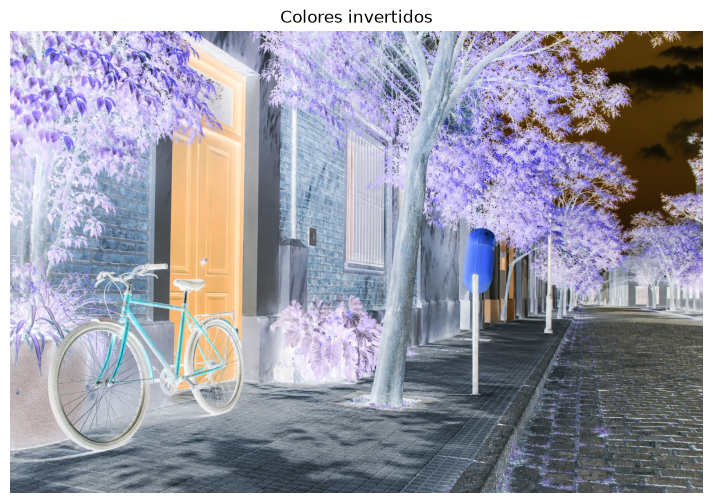

In [63]:
@medir_tiempo
def invertir_colores(imagen_array):
    return 255 - imagen_array


imagen_invertida = invertir_colores(datos)

plt.figure(figsize=(10, 6))
plt.imshow(imagen_invertida)
plt.title("Colores invertidos")
plt.axis("off")
plt.show()


### La lectura profunda

`@medir_tiempo` no cambia qué cálculo realiza `invertir_colores`. Cambia cómo se ejecuta alrededor de ese cálculo. Esta idea reaparece en software real para registrar eventos, validar entradas, controlar permisos, usar caché o medir rendimiento.


---

## 8. Del cuaderno al script

Hasta ahora trabajamos en un espacio interactivo:

- ejecutamos por partes;
- observamos resultados inmediatamente;
- corregimos, comparamos y comunicamos el proceso.

Ahora escribiremos un archivo Python completo. `%%writefile` es una **magia de Jupyter**: toma el contenido de la celda y lo guarda como `app.py`. El script debe ser autónomo; no puede depender de variables que solo existen en la memoria del cuaderno.


In [64]:
%%writefile app.py
from pathlib import Path

import gradio as gr
import numpy as np
from PIL import Image


def ajustar_brillo(imagen, cambio):
    if imagen is None:
        return None

    datos = np.asarray(imagen.convert("RGB"), dtype=np.int16)
    ajustada = np.clip(datos + int(cambio), 0, 255).astype(np.uint8)
    return Image.fromarray(ajustada)


ruta_ejemplo = Path("imagenes") / "escena_urbana.png"
ejemplos = [[str(ruta_ejemplo), 35]] if ruta_ejemplo.exists() else None

demo = gr.Interface(
    fn=ajustar_brillo,
    inputs=[
        gr.Image(type="pil", label="Imagen"),
        gr.Slider(-100, 100, value=0, step=1, label="Cambio de brillo"),
    ],
    outputs=gr.Image(type="pil", label="Resultado"),
    examples=ejemplos,
    title="Laboratorio local de brillo",
)


if __name__ == "__main__":
    demo.launch()


Overwriting app.py


### Ejecutar la aplicación

Desde una terminal nueva de VS Code, en la carpeta de esta clase:

```powershell
uv run python app.py
```

La terminal mostrará una dirección local, normalmente `http://127.0.0.1:7860`. Abrirla en el navegador, cargar una imagen y mover el control de brillo.

Para detener la aplicación, volver a la terminal y pulsar `Ctrl+C`.

### Pregunta de cierre

¿Qué parte del trabajo hizo posible construir la interfaz con tan poco código? La respuesta importante no es “Gradio”: fue haber diseñado una función con entradas y salidas claras.


---

## 9. Cerrar y limpiar el entorno de esta clase

Como cada encuentro tendrá un entorno distinto, al finalizar retiraremos también su kernel.

1. Detener la aplicación Gradio con `Ctrl+C`.
2. Detener el kernel desde VS Code y cerrar el cuaderno.
3. En la terminal, comprobar y eliminar el registro:

```powershell
uv run jupyter kernelspec list
uv run jupyter kernelspec uninstall pdi-c02-python312
```

4. Verificar que ya no aparece:

```powershell
uv run jupyter kernelspec list
```

Si también se elimina el entorno virtual, hacerlo **después** de retirar el kernel:

```powershell
Remove-Item -Recurse -Force .venv
```

El cuaderno, `app.py`, `pyproject.toml` y `uv.lock` permanecen. Si alguna vez necesitamos reconstruir el entorno, `uv sync` volverá a crearlo de manera reproducible.


---

## Cierre conceptual

| Mirada | Objeto principal | Pregunta |
|---|---|---|
| Sistema de archivos | `Path` | ¿Dónde está la imagen? |
| Archivo visual | `PIL.Image` | ¿Cómo la abro, convierto o recorto? |
| Datos numéricos | `numpy.ndarray` | ¿Qué valores contienen sus píxeles? |
| Comunicación visual | Matplotlib | ¿Cómo comparo resultados? |
| Diseño del código | Función | ¿Cómo reutilizo una transformación? |
| Organización | Clase | ¿Cómo reúno estado y operaciones? |
| Comportamiento transversal | Decorador | ¿Cómo añado medición sin alterar la tarea? |
| Automatización | Script | ¿Cómo ejecuto el trabajo fuera del cuaderno? |

El cuaderno fue nuestro laboratorio; el script convirtió una exploración en una herramienta que otra persona puede usar.
